# NLP Mini Project: Traditional Text Classification Pipeline

## Project Overview

In this project, students will build a **complete traditional Natural Language Processing (NLP) machine learning pipeline** for text classification. The focus is on **classical NLP techniques** rather than deep learning.

Students will learn how to:

- Perform text preprocessing
- Apply classical NLP techniques
- Convert text into numerical features
- Train machine learning models
- Evaluate model performance
- Save preprocessing objects and trained models
- Deploy the trained model using a simple FastAPI service

---

## Learning Objectives

By completing this project, students will:

1. Understand the steps of a traditional NLP pipeline
2. Implement text preprocessing techniques
3. Convert text into vector representations (BOW / TF-IDF)
4. Train classical ML models for text classification
5. Evaluate models using proper metrics
6. Save preprocessing pipelines and models
7. Deploy the model as an API using FastAPI

---

# Dataset


### Kaggle Dataset (Optional)

Students may alternatively use an easy Kaggle dataset such as:

Spam Classification

https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset

Task:

Classify SMS messages as:

- spam
- ham

---

# Project Requirements

Students must implement the following pipeline:

1. Data loading
2. Text preprocessing
3. Feature extraction
4. Model training
5. Model evaluation
6. Saving artifacts
7. API deployment

---

# Step 1 — Install Required Libraries

Students may need the following libraries:

- pandas
- numpy
- scikit-learn
- nltk
- spacy
- fastapi
- uvicorn
- joblib

Hint: Install missing libraries using pip.


In [1]:
!pip install -q pandas numpy scikit-learn nltk fastapi uvicorn joblib pyngrok nest-asyncio

import re
import pandas as pd
import numpy as np
import nltk
import joblib

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')

print("All libraries ready")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


All libraries ready


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


# Step 2 — Load Dataset

### Option A: Load the Kaggle dataset

Hint:

Your task:

- Load the dataset
- Convert it into a pandas DataFrame
- Inspect sample rows

Questions:

- How many documents are there?
- How many classes exist?


In [2]:
df = pd.read_csv('spam.csv', encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
print(df.shape)
print(df.dtypes)

(5572, 5)
v1            object
v2            object
Unnamed: 2    object
Unnamed: 3    object
Unnamed: 4    object
dtype: object


In [4]:
df.isnull().sum()

,0
v1,0
v2,0
Unnamed: 2,5522
Unnamed: 3,5560
Unnamed: 4,5566


In [5]:
df = df[['v1', 'v2']]
df.columns = ['label', 'text']
df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
print(f"Duplicates: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Shape after dropping duplicates: {df.shape}")

df['label'].value_counts()

Duplicates: 403
Shape after dropping duplicates: (5169, 2)


,count
label,
ham,4516
spam,653


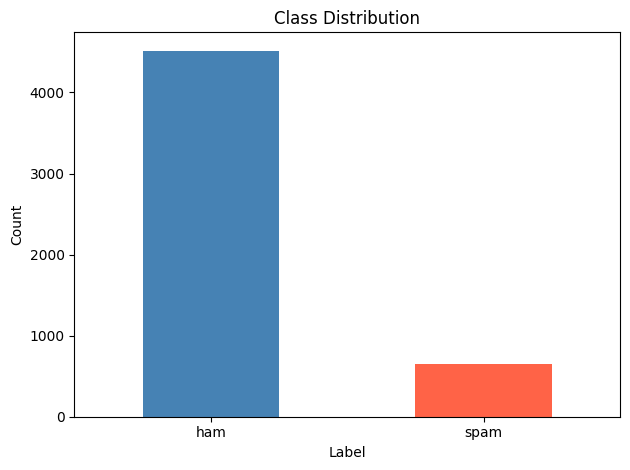

In [12]:
df['label'].value_counts().plot(kind='bar', color=['steelblue','tomato'])
plt.title('Class Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

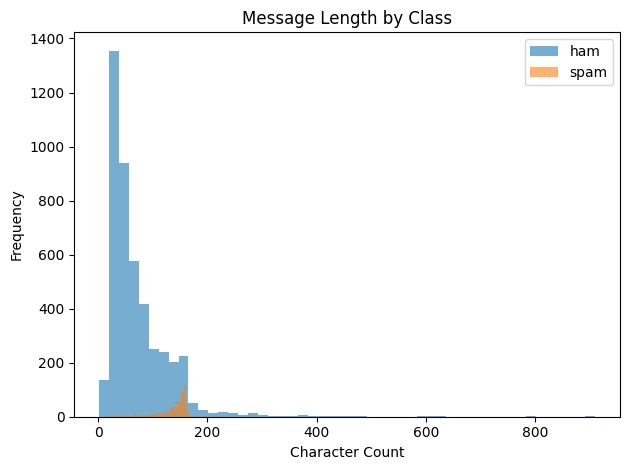

,text_length
label,
ham,70.459256
spam,137.891271


In [13]:
df['text_length'] = df['text'].apply(len)

df.groupby('label')['text_length'].plot(
    kind='hist', bins=50, alpha=0.6, legend=True
)
plt.title('Message Length by Class')
plt.xlabel('Character Count')
plt.tight_layout()
plt.show()

df.groupby('label')['text_length'].mean()

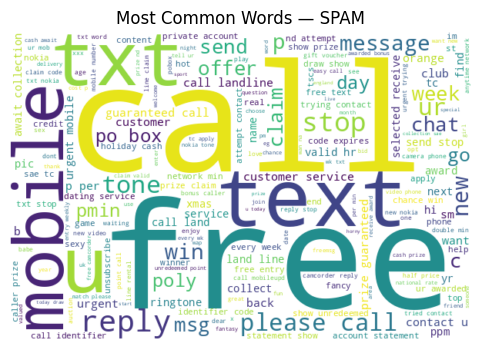

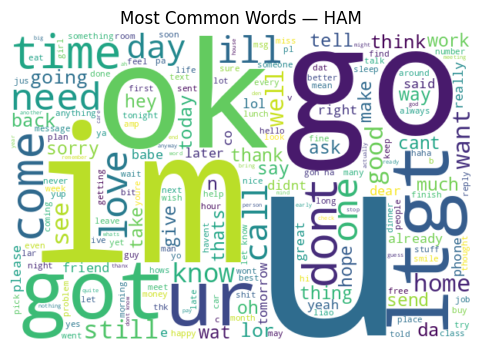

In [14]:
from wordcloud import WordCloud

for label in ['spam', 'ham']:
    text = ' '.join(df[df['label'] == label]['clean_text'])
    wc = WordCloud(width=600, height=400,
                   background_color='white').generate(text)
    plt.figure(figsize=(8,4))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Most Common Words — {label.upper()}')
    plt.show()

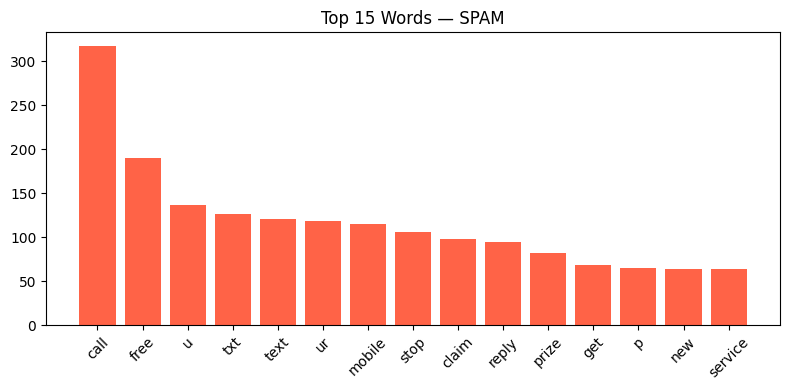

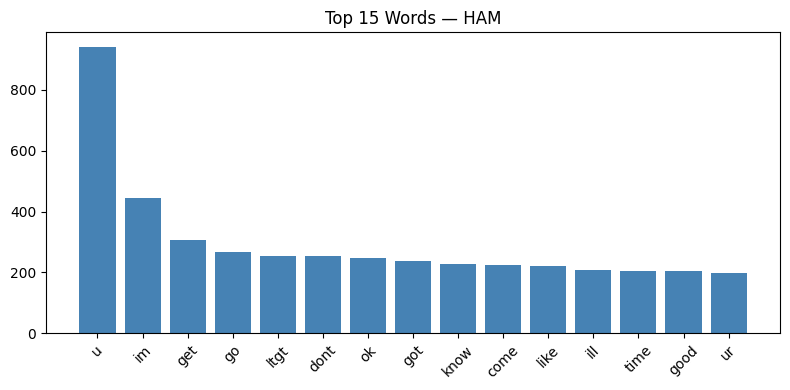

In [15]:
from collections import Counter

for label in ['spam', 'ham']:
    words = ' '.join(df[df['label'] == label]['clean_text']).split()
    common = Counter(words).most_common(15)
    words_, counts_ = zip(*common)
    plt.figure(figsize=(8,4))
    plt.bar(words_, counts_, color='tomato' if label=='spam' else 'steelblue')
    plt.title(f'Top 15 Words — {label.upper()}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Step 3 — Text Preprocessing

Students must implement the following preprocessing steps:

### 1. Case Folding

Convert text to lowercase.

Example:

`"Hello World" → "hello world"`

---

### 2. Remove Punctuation and Numbers

Use **Regular Expressions (re)**.

Hint:

Use `re.sub()`.

---

### 3. Tokenization

Split text into tokens.

Example:

`"machine learning is fun" → ["machine","learning","is","fun"]`

---

### 4. Stopword Removal

Remove common words such as:

- the
- is
- and

Hint:

Use NLTK stopwords.

---

### 5. Stemming

Apply a stemming algorithm.

Example:

- running → run
- played → play

Hint:

Use `PorterStemmer`.

---

### 6. Lemmatization

Convert words to dictionary form.

Example:

- better → good
- running → run

Hint:

Use `WordNetLemmatizer`.

---

### Task

Create a **single preprocessing function** that performs all steps.


In [8]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

print(f"Number of stopwords: {len(stop_words)}")
print(f"Sample stopwords: {list(stop_words)[:10]}")

Number of stopwords: 198
Sample stopwords: ["haven't", 'her', "he'd", "should've", "i've", 'under', 'for', "hasn't", 'have', 'ain']


In [9]:
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

In [10]:
sample = "FREE MONEY!!! Click this link now and WIN prizes!!!"
print("Original :", sample)
print("Processed:", preprocess(sample))

Original : FREE MONEY!!! Click this link now and WIN prizes!!!
Processed: free money click link win prize


In [11]:
df['clean_text'] = df['text'].apply(preprocess)
df[['text', 'clean_text']].head(10)

,text,clean_text
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think go usf life around though
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darling week word back id like fun...
6,Even my brother is not like to speak with me. ...,even brother like speak treat like aid patent
7,As per your request 'Melle Melle (Oru Minnamin...,per request melle melle oru minnaminunginte nu...
8,WINNER!! As a valued network customer you have...,winner valued network customer selected receiv...
9,Had your mobile 11 months or more? U R entitle...,mobile month u r entitled update latest colour...


In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

print(df['label_encoded'].value_counts())

X = df['clean_text']
y = df['label_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size : {len(X_train)}")
print(f"Test size  : {len(X_test)}")

label_encoded
0    4516
1     653
Name: count, dtype: int64
Train size : 4135
Test size  : 1034


# Step 4 — Feature Extraction

Convert text into numeric features.

Students must implement **two techniques**:

### 1. Bag of Words (BOW)

Hint:

`CountVectorizer`

---

### 2. TF-IDF

Hint:

`TfidfVectorizer`

---

Questions:

- What is the difference between BOW and TF-IDF?
- Which one performs better for your dataset?


In [17]:
bow_vectorizer = CountVectorizer()
X_train_bow    = bow_vectorizer.fit_transform(X_train)
X_test_bow     = bow_vectorizer.transform(X_test)

print(f"BOW matrix shape: {X_train_bow.shape}")
print(f"Sample feature names: {bow_vectorizer.get_feature_names_out()[:10]}")

BOW matrix shape: (4135, 6804)
Sample feature names: ['aa' 'aah' 'aaniye' 'aathilove' 'aathiwhere' 'ab' 'abbey' 'abdomen'
 'abeg' 'abel']


In [18]:
tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf    = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf     = tfidf_vectorizer.transform(X_test)

print(f"TF-IDF matrix shape: {X_train_tfidf.shape}")
print(f"Sample feature names: {tfidf_vectorizer.get_feature_names_out()[:10]}")

TF-IDF matrix shape: (4135, 6804)
Sample feature names: ['aa' 'aah' 'aaniye' 'aathilove' 'aathiwhere' 'ab' 'abbey' 'abdomen'
 'abeg' 'abel']


## **Almost certainly TF-IDF Wins — because spam words like "win", "prize", "claim" are rare in ham but frequent in spam, so TF-IDF amplifies exactly those signals.**

# Step 5 — Train Machine Learning Models

Students must train **at least two models**.

Recommended models:

- Logistic Regression
- Naive Bayes
- Linear SVM

Hints:

Split the dataset using:

`train_test_split`

Train models on:

- BOW features
- TF-IDF features


In [19]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Naive Bayes'         : MultinomialNB(),
    'Linear SVM'          : LinearSVC(class_weight='balanced')
}

In [20]:
vectorizers = {
    'BOW'   : (X_train_bow,   X_test_bow),
    'TF-IDF': (X_train_tfidf, X_test_tfidf)
}

trained_models = {}

for vec_name, (Xtr, Xte) in vectorizers.items():
    for model_name, model in models.items():
        model.fit(Xtr, y_train)
        trained_models[f"{model_name}_{vec_name}"] = model
        print(f"Trained: {model_name} + {vec_name}")

Trained: Logistic Regression + BOW
Trained: Naive Bayes + BOW
Trained: Linear SVM + BOW
Trained: Logistic Regression + TF-IDF
Trained: Naive Bayes + TF-IDF
Trained: Linear SVM + TF-IDF


# Step 6 — Model Evaluation

Students must evaluate models using:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

Hint:

Use:

`classification_report`

and

`confusion_matrix`

---

### Analysis Questions

Students must answer:

- Which model performed best?
- Did TF-IDF outperform BOW?
- Why might that happen?


In [21]:
results = []

for vec_name, (Xtr, Xte) in vectorizers.items():
    for model_name, model in models.items():
        key    = f"{model_name}_{vec_name}"
        preds  = trained_models[key].predict(Xte)
        report = classification_report(y_test, preds, output_dict=True)
        results.append({
            'Model'      : model_name,
            'Vectorizer' : vec_name,
            'Accuracy'   : round(report['accuracy'], 4),
            'Precision'  : round(report['weighted avg']['precision'], 4),
            'Recall'     : round(report['weighted avg']['recall'], 4),
            'F1 Score'   : round(report['weighted avg']['f1-score'], 4)
        })

results_df = pd.DataFrame(results).sort_values('F1 Score', ascending=False)
results_df

,Model,Vectorizer,Accuracy,Precision,Recall,F1 Score
5,Linear SVM,TF-IDF,0.9787,0.9785,0.9787,0.9786
3,Logistic Regression,TF-IDF,0.9749,0.9750,0.9749,0.9749
1,Naive Bayes,BOW,0.9729,0.9729,0.9729,0.9718
4,Naive Bayes,TF-IDF,0.9642,0.9652,0.9642,0.9618
2,Linear SVM,BOW,0.9487,0.9621,0.9487,0.9521
0,Logistic Regression,BOW,0.9255,0.9487,0.9255,0.9317


In [22]:
best       = results_df.iloc[0]
best_key   = f"{best['Model']}_{best['Vectorizer']}"
best_vec   = vectorizers[best['Vectorizer']][1]
best_preds = trained_models[best_key].predict(best_vec)

print(f"Best Model: {best_key}\n")
print(classification_report(y_test, best_preds, target_names=['ham', 'spam']))

Best Model: Linear SVM_TF-IDF

              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       903
        spam       0.93      0.90      0.91       131

    accuracy                           0.98      1034
   macro avg       0.96      0.95      0.95      1034
weighted avg       0.98      0.98      0.98      1034



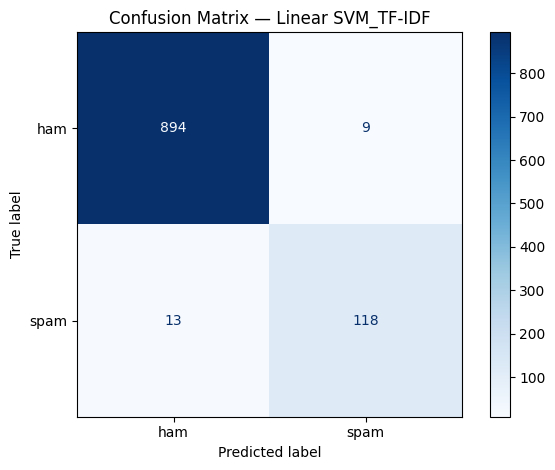

In [23]:
cm   = confusion_matrix(y_test, best_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['ham', 'spam'])
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix — {best_key}")
plt.tight_layout()
plt.show()

# Step 7 — Save Preprocessing and Models

Students must save the following objects:

- text preprocessing pipeline
- vectorizer
- trained model

Use either:

- pickle
- joblib

Example files:

```
preprocessor.pkl
vectorizer.pkl
model.pkl
```

Hints:

Saving models allows reuse without retraining.


In [24]:
best_vectorizer = (
    tfidf_vectorizer if best['Vectorizer'] == 'TF-IDF'
    else bow_vectorizer
)

best_model = trained_models[best_key]

joblib.dump(preprocess,      'preprocess.pkl')
joblib.dump(best_vectorizer, 'vectorizer.pkl')
joblib.dump(best_model,      'model.pkl')

print("preprocess.pkl  saved")
print("vectorizer.pkl  saved")
print("model.pkl       saved")

preprocess.pkl  saved
vectorizer.pkl  saved
model.pkl       saved


In [25]:
loaded_preprocess  = joblib.load('preprocess.pkl')
loaded_vectorizer  = joblib.load('vectorizer.pkl')
loaded_model       = joblib.load('model.pkl')

# Quick test
test_msg = "Congratulations! You won a FREE prize, call now!"
cleaned  = loaded_preprocess(test_msg)
vectored = loaded_vectorizer.transform([cleaned])
pred     = loaded_model.predict(vectored)[0]
label    = le.inverse_transform([pred])[0]

print(f"Message   : {test_msg}")
print(f"Cleaned   : {cleaned}")
print(f"Prediction: {label.upper()}")

Message   : Congratulations! You won a FREE prize, call now!
Cleaned   : congratulation free prize call
Prediction: SPAM


# Step 8 — Build a FastAPI Model Service

Students will create a simple **prediction API**.

### Goal

Send text → receive predicted class.

---

## Project Structure

Suggested folder structure:

```
nlp_project
│
├── model.pkl
├── vectorizer.pkl
├── preprocess.pkl
│
├── app.py
└── notebook.ipynb
```

---

## FastAPI Implementation Hints

Steps:

1. Load saved objects
2. Create API endpoint
3. Accept input text
4. Apply preprocessing
5. Vectorize text
6. Predict label
7. Return prediction

---

### Example Endpoint

`POST /predict`

Input:

```
{
  "text": "Free money!!! Click this link"
}
```

Output:

```
{
  "prediction": "spam"
}
```

---

### Run the API

Students should run:

```
uvicorn app:app --reload
```

Then open:

http://127.0.0.1:8000/docs

to test the API using Swagger UI.


In [26]:
%%writefile app.py

from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# --- Load artifacts ---
preprocess_fn = joblib.load('preprocess.pkl')
vectorizer    = joblib.load('vectorizer.pkl')
model         = joblib.load('model.pkl')

# --- App ---
app = FastAPI(title="Spam Classifier API 🚀")

class TextInput(BaseModel):
    text: str

@app.get("/")
def root():
    return {"message": "Spam Classifier is running!"}

@app.post("/predict")
def predict(data: TextInput):
    cleaned    = preprocess_fn(data.text)
    vectorized = vectorizer.transform([cleaned])
    pred       = model.predict(vectorized)[0]
    label      = "spam" if pred == 1 else "ham"
    return {
        "input"     : data.text,
        "cleaned"   : cleaned,
        "prediction": label
    }

Writing app.py


In [27]:
import threading
import uvicorn
import nest_asyncio

nest_asyncio.apply()

def run():
    uvicorn.run("app:app", port=8000)

thread = threading.Thread(target=run, daemon=True)
thread.start()
print("FastAPI running at http://localhost:8000")

FastAPI running at http://localhost:8000


In [29]:
import gradio as gr
import requests

def predict_spam(text):
    response = requests.post(
        "http://localhost:8000/predict",
        json={"text": text}
    )
    result     = response.json()
    prediction = result['prediction'].upper()
    cleaned    = result['cleaned']
    return prediction, cleaned

demo = gr.Interface(
    fn=predict_spam,
    inputs=gr.Textbox(
        lines=4,
        placeholder="Type or paste any SMS message here...",
        label="📩 Input Message"
    ),
    outputs=[
        gr.Label(label="🔍 Prediction"),
        gr.Textbox(
            lines=3,
            label="🧹 Cleaned Text",
            interactive=False
        )
    ],
    title="📩 SMS Spam Classifier",
    description="Enter any SMS message to check if it's **SPAM** or **HAM** (legit).",
    examples=[
        ["Free entry WIN a prize! Call now!!!"],
        ["Hey, are you coming to the meeting tomorrow?"],
        ["URGENT! You have won £1000. Claim now!"],
        ["Ok lar, joking wif u oni..."]
    ],
    flagging_mode="never"   # ← removes the ugly Flag button
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d1930f45fccba03dae.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# Bonus Tasks (Optional)

Students can extend the project by:

- Creating a scikit-learn Pipeline
- Performing hyperparameter tuning
- Adding model comparison plots
- Deploying the API with Docker
- Building a simple Streamlit UI
